In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib/x86_64-linux-gnu/libm.so.6: version `GLIBC_2.29' not found (required by /home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:72: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:99: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace:

# Pre-processing

/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:251: UserWarning: If you pass `n_top_genes`, all cutoffs are ignored.
  warnings.warn(msg, UserWarning)


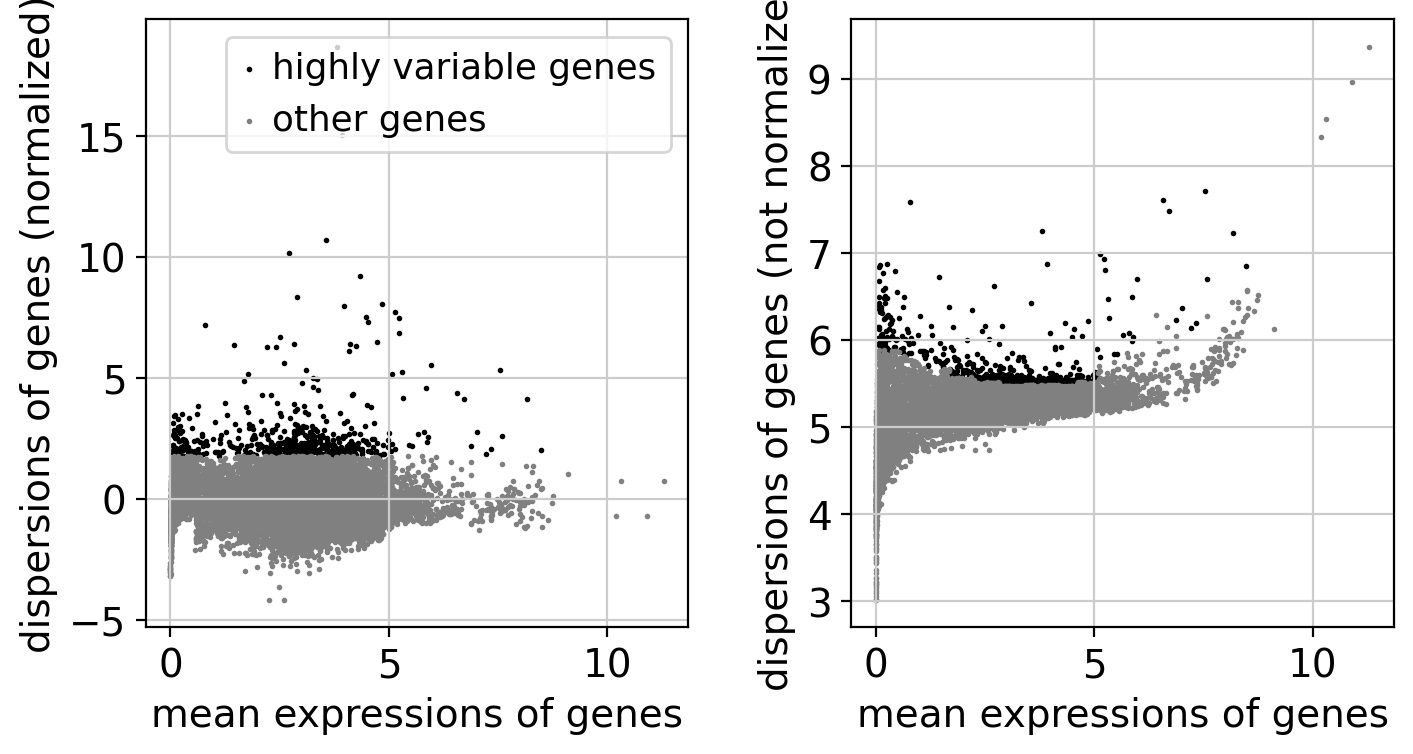

there are 500 hvgs


In [2]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
genes += ['IFNGR1','IFNGR2','JAK1','JAK2','STAT1','IFNG','JAK1','TYK2','IFNAR1','IFNAR2','STAT2','IRF9','IFNA1','IFNB1']
genes = avis.var_names.intersection(list(set(genes)))

In [3]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis = avis[:, genes].copy()
# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis.X = csr_matrix(torch.div(x, norm_factor))
avis.var_names.name = None
avis.write_h5ad('data/250714_preproc_spleen.h5ad')

# Run inference module to learn intra- and inter-cellular gene-gene forces

In [4]:
# load model
from celcomen.models.celcomen import celcomen
from celcomen.training_plan.train import train
from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [5]:
from torch_geometric.loader import DataLoader
import scanpy as sc
import torch
import torch_geometric
#from torch_cluster.knn import knn_graph
from sklearn.neighbors import kneighbors_graph
import numpy as np

from scipy.spatial.distance import pdist, squareform

def get_dataset_loaders(h5ad_path: str, sample_id_name: str, n_neighbors: int, device: str, verbose: bool):
    """
    Prepares and returns PyTorch Geometric DataLoader from a single-cell spatial transcriptomics dataset.

    The function reads a single-cell AnnData object from an H5AD file, normalises the data, and generates 
    graph data where nodes correspond to cells, and edges are created based on spatial proximity using 
    a k-nearest neighbours graph. The data is then loaded into a PyTorch Geometric `DataLoader`.

    Parameters
    ----------
    h5ad_path : str
        Path to the H5AD file containing the raw counts of the single-cell spatial transcriptomics data.
    sample_id_name : str
        Name of the sample ID column in `adata.obs` to separate the dataset into different samples.
    n_neighbors : int
        Number of neighbours to use for constructing the k-nearest neighbours graph for spatial information.
    verbose : bool
        If True, prints detailed information about the DataLoader during the loading process.

    Returns
    -------
    DataLoader
        A PyTorch Geometric DataLoader containing the processed graph data, with each graph representing
        a sample of cells in the dataset.

    Notes
    -----
    - The spatial positions of the cells are used to create a k-nearest neighbours graph, with edges
      connecting cells that are spatially close to each other.
    - The input features for the graph (`x`) are normalised before constructing the graph.
    - `adata.obsm["spatial"]` is used to extract the spatial coordinates of the cells.
    - The graph data is validated using PyTorch Geometric's built-in validation method.

    Examples
    --------
    >>> loader = get_dataset_loaders('data.h5ad', 'sample_id', n_neighbors=6, verbose=True)
    Step 1
    =====
    Number of graphs in the current batch: 1
    Data(x=[100, 33500], edge_index=[2, 500], pos=[100, 2], y=[1])

    Raises
    ------
    ValueError
        If there are issues with the input data during validation, e.g., if the graph is not well-formed.
    """

    adata = sc.read_h5ad(h5ad_path) 

    # sc.pp.normalize_total(adata, target_sum=1e6)
    # sc.pp.log1p(adata)

    adata_list = [  adata[adata.obs[sample_id_name]==i] for i in set(adata.obs[sample_id_name])  ]

    data_list = []
    n_neighbors = 6

    for adata in adata_list:
        pos = torch.from_numpy(adata.obsm["spatial"])
        x = torch.from_numpy(adata.X.todense())    
        # normalize x 
        norm_factor = torch.pow(x,2).sum(1).reshape(-1,1)
        x = torch.div(x, norm_factor)
        y = torch.Tensor([0])   # here we will store GT value
        # compute the edges as two cell widths apart so 30µm
        edge_index = torch.from_numpy(np.array(np.where(kneighbors_graph(adata.obsm['spatial'], n_neighbors=6, include_self=False).toarray() == 1))).to(device)
        data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
        data.validate(raise_on_error=True)    # performs basic checks on the graph
        data_list.append(data)

    loader = DataLoader( data_list, batch_size=1, shuffle=True)

    if verbose:
        for step, data in enumerate(loader):
            print(f'Step {step+1}')
            print("=====")
            print(f'Number of graphs in the current batch: {data.num_graphs}')
            print(data)
            print()

    return loader

In [6]:
# load in spleen and lymph node
n_neighbors = 6
loader = get_dataset_loaders('data/250714_preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 512], edge_index=[2, 18600], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 512], edge_index=[2, 12912], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 512], edge_index=[2, 18618], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 512], edge_index=[2, 14592], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])



### Select the hyperparameters of the model.
zmft_scalar should be the highest value in the range (0,1) such that the loss can be stably minimized. 
n_neighbors should be selected based on what disentanglement we want to achieve in the data. n_neighbors=6 targets disentanglement between intracellular and intercellular forces of short range.

In [7]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-3
zmft_scalar = 1e-1
seed = 0
epochs = 20

# instantiate models on cpu
model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model.set_g2g(torch.from_numpy(input_g2g))
model.set_g2g_intra(torch.from_numpy(input_g2g))
model.to('cpu')
# train the models
losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|███████████████████████████████████████████| 20/20 [00:07<00:00,  2.75it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

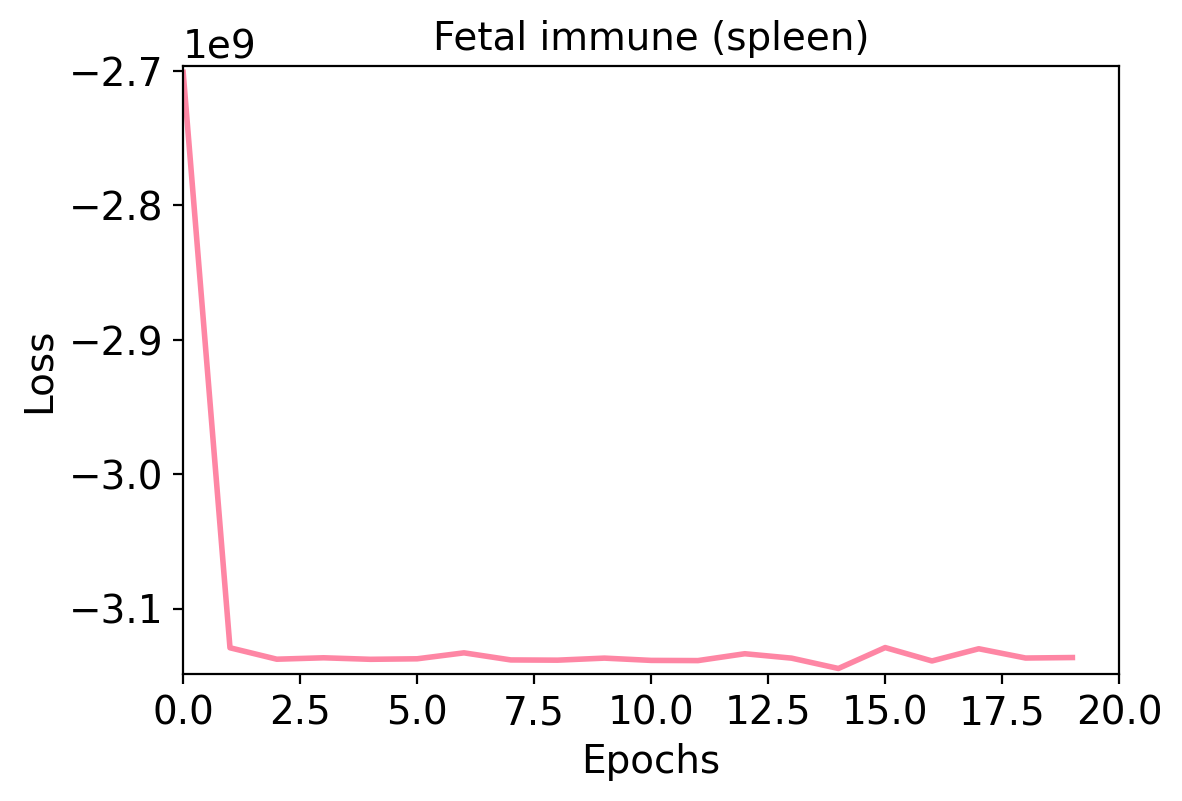

In [8]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses), 0), max(losses)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

# Confirm protein localization

In [9]:
# define the gene
secs = pd.read_table('../ccc/data/external/goids/quickgo_secreted.tsv')['SYMBOL'].unique()
sps = pd.read_table('../ccc/data/external/goids/quickgo_surfaceprotein.tsv')['SYMBOL'].unique()
nons = pd.Index(genes)[(~pd.Index(genes).isin(secs))&(~pd.Index(genes).isin(sps))]
secs = pd.Index(genes).intersection(secs)
sps = pd.Index(genes).intersection(sps)

/loc/scratch/26446548/ipykernel_36551/3621708536.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/26446548/ipykernel_36551/3621708536.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/26446548/ipykernel_36551/3621708536.py:16: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/26446548/ipykernel_36551/3621708536.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be remov

7.309416696265475e-25
0.0013560955928766244
7.631934591366336e-15


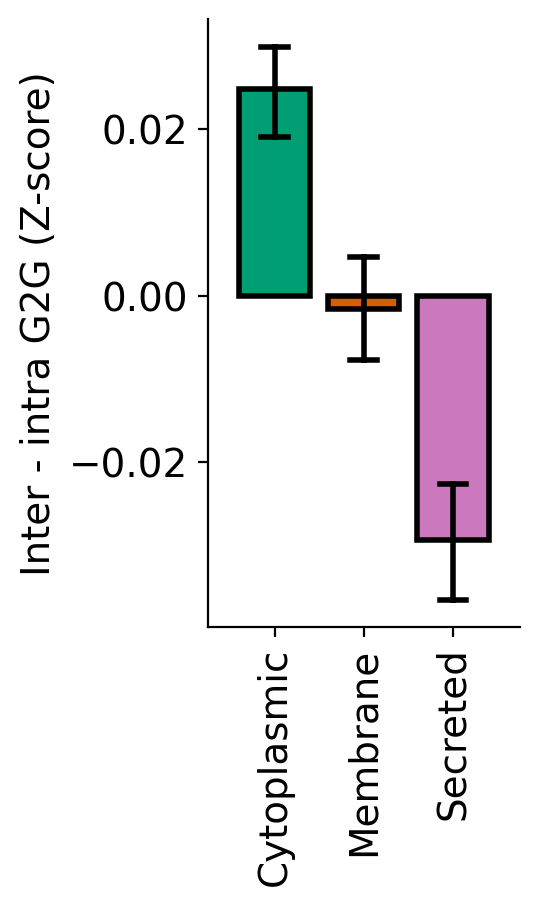

In [10]:
# derive an integrated gene-gene matrix
g2g_intracellular = pd.DataFrame(model.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intercellular = pd.DataFrame(model.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
# derive the values
diffs_secs = (g2g_intercellular.loc[secs, :] - g2g_intracellular.loc[secs, :]).values.flatten()
diffs_sps = (g2g_intercellular.loc[sps, :] - g2g_intracellular.loc[sps, :]).values.flatten()
diffs_nons = (g2g_intercellular.loc[nons, :] - g2g_intracellular.loc[nons, :]).values.flatten()
# assemble them
ys = np.hstack([diffs_secs, diffs_sps, diffs_nons])
ys -= ys.mean()
ys /= ys.std()
xs = np.array(['Secreted']*len(diffs_secs)+['Membrane']*len(diffs_sps)+['Cytoplasmic']*len(diffs_nons))
# create plot
fig, ax = plt.subplots(figsize=[2, 4])
ax.grid(False)
sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
            errcolor='k', edgecolor='k', palette=['#cc78bc','#d55e00','#029e73'][::-1])
ax.set_xlim(-0.75, 2.75)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Inter - intra G2G (Z-score)')
ax.spines[['right', 'top']].set_visible(False)
# derive pvalues
p1 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Membrane'])[1]
p2 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Cytoplasmic'])[1]
p3 = ss.mannwhitneyu(ys[xs == 'Cytoplasmic'], ys[xs == 'Membrane'])[1]
print(p1, p2, p3, sep='\n')

# Interpret gene interaction matrices (intracellular)

In [18]:
# look at the genes of interest
genes_ = ['IFNAR1', 'IFNAR2', 'IFNB1', 'IFNG', 'IFNGR1', 'IFNGR2', 'IRF9', 'JAK1', 'JAK2', 'STAT1', 'STAT2', 'TYK2']
g2g_intracellular.loc[genes_][genes_]

SYMBOL,IFNAR1,IFNAR2,IFNB1,IFNG,IFNGR1,IFNGR2,IRF9,JAK1,JAK2,STAT1,STAT2,TYK2
SYMBOL,,,,,,,,,,,,
IFNAR1,1.000000,1.000000,0.007843,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
IFNAR2,1.000000,1.000000,0.006516,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
IFNB1,0.007843,0.006516,1.000000,0.657919,0.0082,0.006148,0.006371,0.010502,0.001633,0.00776,0.005717,0.006597
IFNG,1.000000,1.000000,0.657919,1.000000,1.0000,1.000000,1.000000,1.000000,0.467869,1.00000,1.000000,1.000000
IFNGR1,1.000000,1.000000,0.008200,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
IFNGR2,1.000000,1.000000,0.006148,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
IRF9,1.000000,1.000000,0.006371,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
JAK1,1.000000,1.000000,0.010502,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
JAK2,1.000000,1.000000,0.001633,0.467869,1.0000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [19]:
# repeat for extracellular
g2g_intercellular.loc[genes_][genes_]

SYMBOL,IFNAR1,IFNAR2,IFNB1,IFNG,IFNGR1,IFNGR2,IRF9,JAK1,JAK2,STAT1,STAT2,TYK2
SYMBOL,,,,,,,,,,,,
IFNAR1,1.000000,1.000000,0.017234,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
IFNAR2,1.000000,1.000000,0.012931,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
IFNB1,0.017234,0.012931,1.000000,0.645380,0.025409,0.019661,0.012467,0.025781,0.005680,0.016993,0.017904,0.013174
IFNG,1.000000,1.000000,0.645380,1.000000,1.000000,1.000000,1.000000,1.000000,0.123443,1.000000,1.000000,1.000000
IFNGR1,1.000000,1.000000,0.025409,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
IFNGR2,1.000000,1.000000,0.019661,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
IRF9,1.000000,1.000000,0.012467,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
JAK1,1.000000,1.000000,0.025781,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
JAK2,1.000000,1.000000,0.005680,0.123443,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Pre-processing

In [84]:
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# define the sample indexing
avis.obs['sample_id'] = 'sample'
avis.obsm['spatial'] = avis.obs[['imagerow','imagecol']].values
sc.pp.filter_cells(avis, min_counts=1)

In [85]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis = avis[:, genes].copy()
# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis.X = csr_matrix(torch.div(x, norm_factor))
avis.var_names.name = None
avis.write_h5ad('data/250714_preproc_ln.h5ad')

In [86]:
# load in spleen and lymph node
n_neighbors = 6
loader = get_dataset_loaders('data/250714_preproc_ln.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 500], edge_index=[2, 24210], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



In [87]:
# instantiate models on cpu
model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model.set_g2g(torch.from_numpy(input_g2g))
model.set_g2g_intra(torch.from_numpy(input_g2g))
model.to('cpu')
# train the models
losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|███████████████████████████████████████████| 20/20 [00:03<00:00,  6.49it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult immune (lymph node)')]

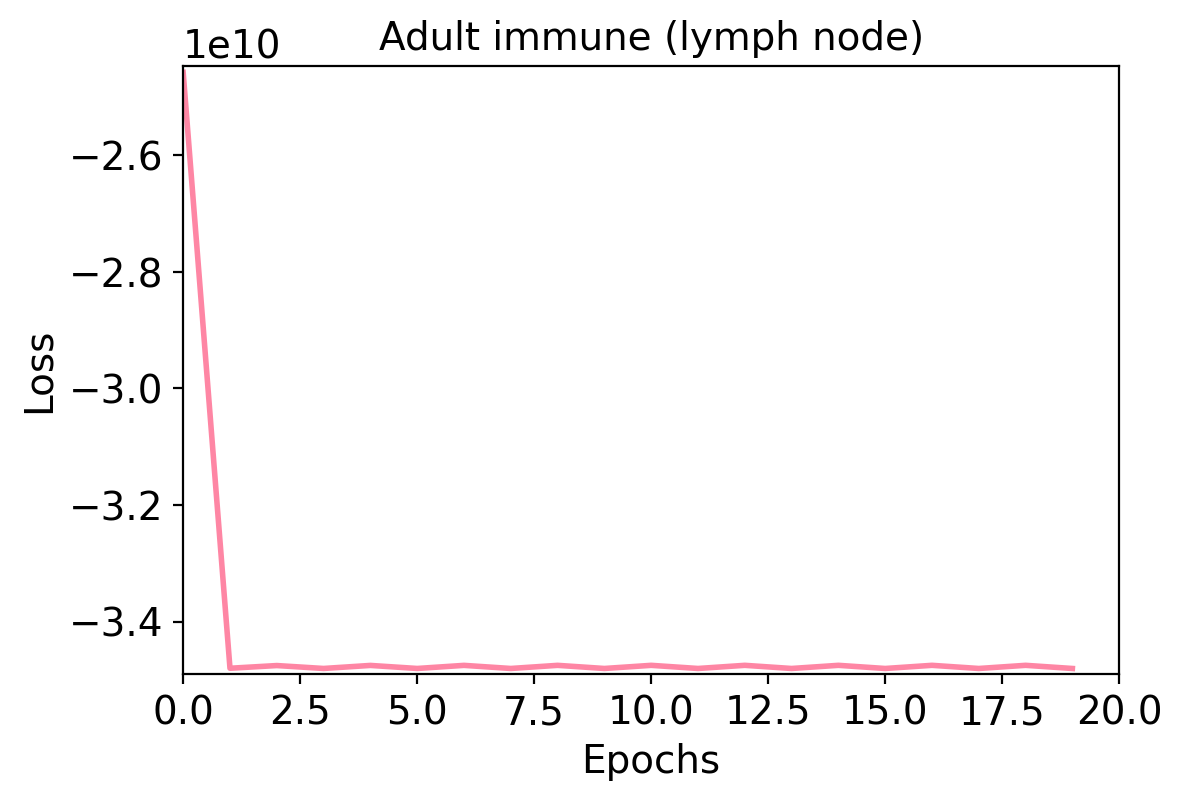

In [88]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
vmin, vmax = min(min(losses), 0), max(losses)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')

In [89]:
# define the gene
secs = pd.read_table('../ccc/data/external/goids/quickgo_secreted.tsv')['SYMBOL'].unique()
sps = pd.read_table('../ccc/data/external/goids/quickgo_surfaceprotein.tsv')['SYMBOL'].unique()
nons = pd.Index(genes)[(~pd.Index(genes).isin(secs))&(~pd.Index(genes).isin(sps))]
secs = pd.Index(genes).intersection(secs)
sps = pd.Index(genes).intersection(sps)

/loc/scratch/26144723/ipykernel_16388/3621708536.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/26144723/ipykernel_16388/3621708536.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/26144723/ipykernel_16388/3621708536.py:16: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'k'}` instead.

  sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
/loc/scratch/26144723/ipykernel_16388/3621708536.py:16: FutureWarning: 

The `errwidth` parameter is deprecated. And will be remov

0.00014312595352398538
4.277978264393874e-14
0.00046449392409471363


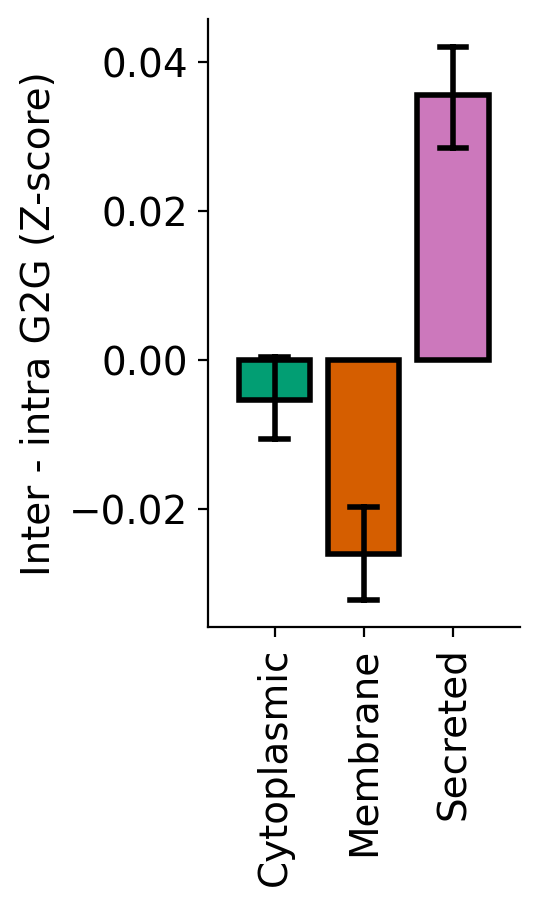

In [90]:
# derive an integrated gene-gene matrix
g2g_intracellular = pd.DataFrame(model.lin.weight.detach().numpy(), index=genes, columns=genes)
g2g_intercellular = pd.DataFrame(model.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
# derive the values
diffs_secs = (g2g_intercellular.loc[secs, :] - g2g_intracellular.loc[secs, :]).values.flatten()
diffs_sps = (g2g_intercellular.loc[sps, :] - g2g_intracellular.loc[sps, :]).values.flatten()
diffs_nons = (g2g_intercellular.loc[nons, :] - g2g_intracellular.loc[nons, :]).values.flatten()
# assemble them
ys = np.hstack([diffs_secs, diffs_sps, diffs_nons])
ys -= ys.mean()
ys /= ys.std()
xs = np.array(['Secreted']*len(diffs_secs)+['Membrane']*len(diffs_sps)+['Cytoplasmic']*len(diffs_nons))
# create plot
fig, ax = plt.subplots(figsize=[2, 4])
ax.grid(False)
sns.barplot(x=xs[::-1], y=ys[::-1], saturation=1, ci=95, errwidth=2, capsize=0.3, linewidth=2,
            errcolor='k', edgecolor='k', palette=['#cc78bc','#d55e00','#029e73'][::-1])
ax.set_xlim(-0.75, 2.75)
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Inter - intra G2G (Z-score)')
ax.spines[['right', 'top']].set_visible(False)
# derive pvalues
p1 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Membrane'])[1]
p2 = ss.mannwhitneyu(ys[xs == 'Secreted'], ys[xs == 'Cytoplasmic'])[1]
p3 = ss.mannwhitneyu(ys[xs == 'Cytoplasmic'], ys[xs == 'Membrane'])[1]
print(p1, p2, p3, sep='\n')

In [91]:
g2g_intracellular.sum(1).sort_values()[::-1][:25]

IGKC        447.000000
IGLC2       442.105896
IGHM        434.491852
CCL21       432.805786
IGHA1       427.263367
HLA-DRA     424.797699
JCHAIN      414.801331
CD52        413.702118
IGLC3       406.098633
CCL19       389.791077
LYZ         385.396790
HLA-DRB5    379.469604
SPARC       374.983643
C7          374.885651
TAGLN       374.124390
BMPR1A      372.706360
CHD3        370.725525
TBX2        370.593109
ELN         370.482666
MT2A        370.229431
SFRP2       369.839111
GALNT3      369.477875
PLCG2       369.095276
PWP2        368.970886
F13A1       368.881989
dtype: float32

In [92]:
g2g_intracellular.index[g2g_intracellular.index.str.startswith('IL')]

Index(['IL7', 'IL17B'], dtype='object')

In [93]:
g2g_intracellular.index[g2g_intracellular.index.str.startswith('STAT')]

Index([], dtype='object')

In [94]:
g2g_intracellular.index[g2g_intracellular.index.str.startswith('JAK')]

Index([], dtype='object')